# CPI on xi * oil: OLS Regression with Country Fixed Effects

This notebook runs OLS of annual CPI percentage change on `xi * oil_pct_change` with configurable CPI lags and optional country fixed effects, joined by country code and year.


In [66]:
from pathlib import Path
import sys
import importlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from io_networks import regression
importlib.reload(regression)


In [67]:
xi_path = ROOT / "data/processed/xi/regular/xi_by_country_year.parquet"
c_path = ROOT / "data/processed/c/regular/c_by_country_year.parquet"
c_diff_path = ROOT / "data/processed/c_diff/regular/c_diff_by_country_year.parquet"
cpi_freq = "A"  # "A", "M", or "Q"
cpi_path = {
    "A": ROOT / "data/processed/cpi/annual_cpi.csv",
    "M": ROOT / "data/processed/cpi/monthly_cpi.csv",
    "Q": ROOT / "data/processed/cpi/quarterly_cpi.csv",
}[cpi_freq]
oil_path = {
    "A": ROOT / "data/processed/oil/annual_oil.csv",
    "M": ROOT / "data/processed/oil/monthly_oil.csv",
    "Q": ROOT / "data/processed/oil/quarterly_oil.csv",
}[cpi_freq]

xi_df = regression.load_xi(xi_path)
c_df = regression.load_c(c_path)
c_diff_df = regression.load_c_diff(c_diff_path)
cpi_df = regression.load_cpi_pct_change(cpi_path, freq=cpi_freq)
oil_df = regression.load_oil_pct_change(oil_path, freq=cpi_freq)
reg_df = regression.prepare_regression_df(xi_df, c_df, cpi_df, oil_df, c_diff_df=c_diff_df)

print("Rows:", len(reg_df))
print("Countries:", reg_df["country"].nunique())
print("Years:", int(reg_df["year"].min()), "-", int(reg_df["year"].max()))
reg_df.head()


AttributeError: module 'regression' has no attribute 'load_c'

In [ ]:
cpi_lags = 1
include_country_fe = False
regressand_mode = "cpi_minus_c"  # "cpi", "cpi_minus_xi_x_oil", "cpi_minus_c" (annual only), "cpi_minus_xi_x_oil_c", "cpi_minus_xi_x_oil_c_diff" (annual only), or "cpi_on_xi_x_oil_and_c_diff"
exclude_argentina = True

print("cpi_lags:", cpi_lags)
print("include_country_fe:", include_country_fe)
print("regressand_mode:", regressand_mode)
print("exclude_argentina:", exclude_argentina)


cpi_lags: 3
include_country_fe: False
regressand_mode: cpi_minus_xi_x_oil
exclude_argentina: True


In [ ]:
reg_df_model = regression.exclude_countries(reg_df, ["ARG"]) if exclude_argentina else reg_df.copy()

model, coef_df = regression.run_ols(
    reg_df_model,
    cpi_lags=cpi_lags,
    include_country_fe=include_country_fe,
    regressand=regressand_mode,
)
coef_df


,term,coef,std_err_hc3,t,p_value,ci_low_95,ci_high_95
0,const,0.214413,0.136903,1.566165,0.117310,-0.053912,0.482739
1,xi_x_oil,2.591358,21.259214,0.121893,0.902983,-39.075936,44.258653
2,cpi_pct_change_lag1,0.128074,0.518723,0.246902,0.804984,-0.888604,1.144752
3,cpi_pct_change_lag2,0.004671,0.388779,0.012015,0.990414,-0.757321,0.766663
4,cpi_pct_change_lag3,0.144333,0.400196,0.360654,0.718358,-0.640038,0.928703


In [ ]:
if include_country_fe:
    fe = pd.get_dummies(reg_df_model["country"], prefix="country_fe", drop_first=True, dtype=float)
    print("FE dummy columns:", fe.shape[1])
    print("Example FE columns:", fe.columns[:10].tolist())
    fe.head()
else:
    print("Country FE disabled for this run.")


Country FE disabled for this run.


In [ ]:
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:             regressand   R-squared:                       0.213
Model:                            OLS   Adj. R-squared:                  0.210
Method:                 Least Squares   F-statistic:                    0.1299
Date:                Fri, 13 Feb 2026   Prob (F-statistic):              0.972
Time:                        22:05:30   Log-Likelihood:                -581.26
No. Observations:                1118   AIC:                             1173.
Df Residuals:                    1113   BIC:                             1198.
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   0.2144    

In [ ]:
fe_terms = coef_df[coef_df["term"].str.startswith("country_fe_")].copy()
print("Estimated country FE terms:", len(fe_terms))
fe_terms.head()


Estimated country FE terms: 0


,term,coef,std_err_hc3,t,p_value,ci_low_95,ci_high_95


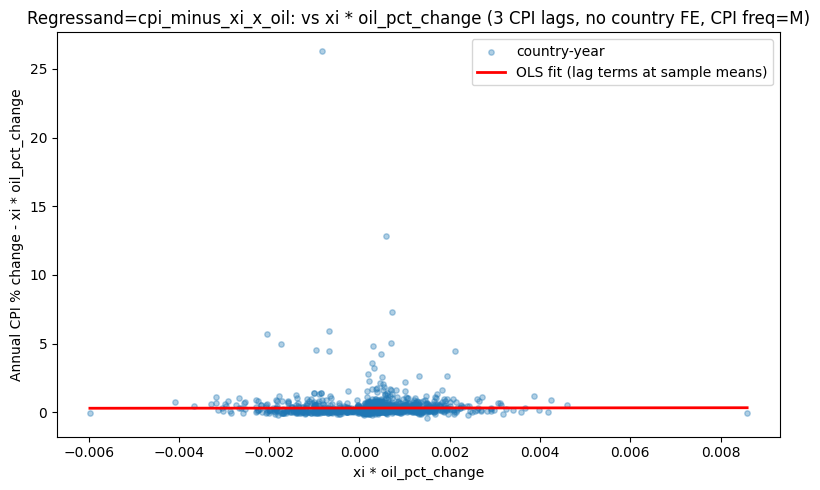

In [ ]:
x = reg_df_model["xi_x_oil"].to_numpy()
if regressand_mode == "cpi_minus_xi_x_oil":
    y = (reg_df_model["cpi_pct_change"] - reg_df_model["xi_x_oil"]).to_numpy()
    y_label = "Annual CPI % change - xi * oil_pct_change"
elif regressand_mode == "cpi_minus_xi_x_oil_c":
    y = (reg_df_model["cpi_pct_change"] - reg_df_model["xi_x_oil"] - reg_df_model["c"]).to_numpy()
    y_label = "Annual CPI % change - xi * oil_pct_change - c"
elif regressand_mode == "cpi_minus_xi_x_oil_c_diff":
    y = (reg_df_model["cpi_pct_change"] - reg_df_model["xi_x_oil"] - reg_df_model["c_diff"]).to_numpy()
    y_label = "Annual CPI % change - xi * oil_pct_change - c_diff"
elif regressand_mode == "cpi_minus_c":
    y = (reg_df_model["cpi_pct_change"] - reg_df_model["c"]).to_numpy()
    y_label = "Annual CPI % change - c"
elif regressand_mode == "cpi_on_xi_x_oil_and_c_diff":
    y = reg_df_model["cpi_pct_change"].to_numpy()
    y_label = "Annual CPI % change (regressed on xi * oil_pct_change and c_diff)"
else:
    y = reg_df_model["cpi_pct_change"].to_numpy()
    y_label = "Annual CPI percentage change"

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.35, s=15, label="country-year")

x_line = np.linspace(x.min(), x.max(), 100)
y_line = model.params["const"] + model.params["xi_x_oil"] * x_line
for lag in range(1, cpi_lags + 1):
    term = f"cpi_pct_change_lag{lag}"
    lag_mean = (
        reg_df_model.sort_values(["country", "year"])
        .groupby("country")["cpi_pct_change"]
        .shift(lag)
        .mean()
    )
    if term in model.params.index:
        y_line += model.params[term] * lag_mean
if "c_diff" in model.params.index:
    y_line += model.params["c_diff"] * reg_df_model["c_diff"].mean()

plt.plot(x_line, y_line, color="red", linewidth=2, label="OLS fit (lag terms at sample means)")

plt.xlabel("xi * oil_pct_change")
plt.ylabel(y_label)
fe_label = "with country FE" if include_country_fe else "no country FE"
plt.title(
    f"Regressand={regressand_mode}: vs xi * oil_pct_change ({cpi_lags} CPI lags, {fe_label}, CPI freq={cpi_freq})"
)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
out_dir = ROOT / "outputs/regression"
paths = regression.save_outputs(reg_df_model, coef_df, model, out_dir)
paths


{'merged_data': WindowsPath('c:/Users/user/Projects/Academics/0. Dissertation/analysis/outputs/regression/cpi_xi_oil_regression_data.csv'),
 'coefficients': WindowsPath('c:/Users/user/Projects/Academics/0. Dissertation/analysis/outputs/regression/cpi_xi_oil_ols_coefficients.csv'),
 'summary': WindowsPath('c:/Users/user/Projects/Academics/0. Dissertation/analysis/outputs/regression/cpi_xi_oil_ols_summary.txt'),
 'metrics': WindowsPath('c:/Users/user/Projects/Academics/0. Dissertation/analysis/outputs/regression/cpi_xi_oil_ols_metrics.csv')}